Dataset:
     Category                                           Masseges
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham              Will Ì_ b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]

First 5 rows:
  Category                                           Masseges
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Jokin

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset cleaned successfully!


,Mean,Median,Mode,Minimum,Maximum,Range,Variance,Standard Deviation
Message_Length,78.977945,60.0,22.0,2,910,908,3391.465845,58.236293
Spam_Flag,0.126330,0.0,0.0,0,1,1,0.110392,0.332253


,Message_Length,Spam_Flag
Message_Length,1.000000,0.384717
Spam_Flag,0.384717,1.000000


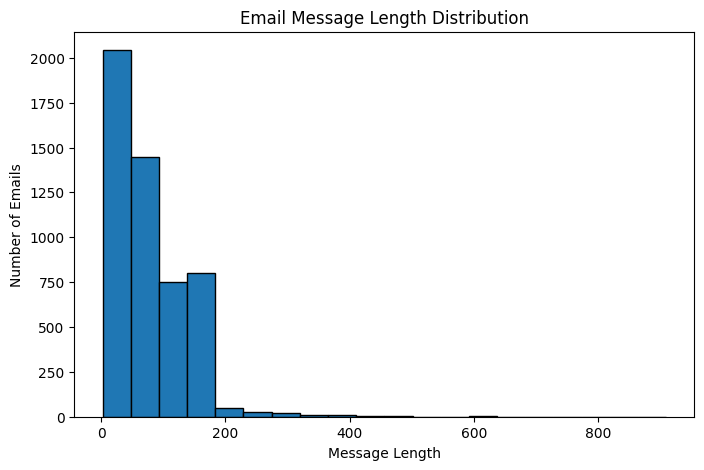

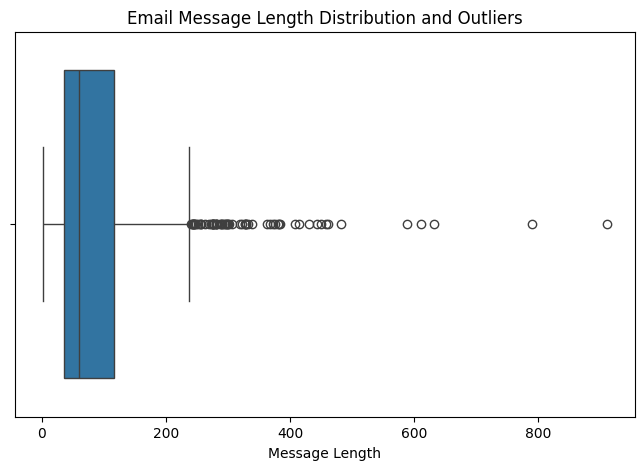

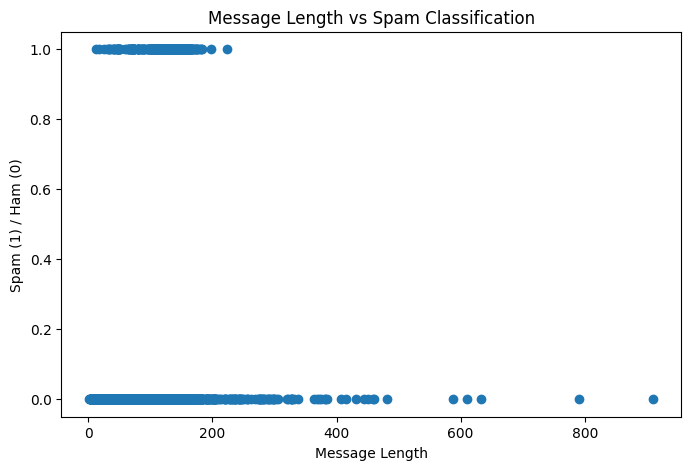

Feature:
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: Masseges, dtype: object

Target:
0     ham
1     ham
2    spam
3     ham
4     ham
Name: Category, dtype: object

Sample Predictions:

Message: Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens
Prediction: ham

Message: I sent my scores to sophas and i had to do secondary application for a few schools. I think if you are thinking of applying, do a research on cost also. Contact joke ogunrinde, her school is one me the less expensive ones
Prediction: ham

Message: We know someone who you know that fancies you. Call 09058097218 to find out who. POBox 6, LS15HB 150p
Prediction: ham

Message: Only if you 

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/spam mail.csv')

print("Dataset:")
print(df)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nLabel Counts:")
print(df["Category"].value_counts())


#Data Handling and Preprocessing

print(df.isnull().sum())
print(df.duplicated().sum())

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_columns.tolist())

categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns.tolist())

df['Masseges'] = df['Masseges'].fillna('')

df['Category'] = df['Category'].fillna(
    df['Category'].mode()[0]
)

df = df.drop_duplicates()

print(df.isnull().sum())

display(df.head())

df.to_excel("Cleaned_Email_Spam_Dataset.xlsx", index=False)

print("\nDataset cleaned successfully!")




# Probability & Statistics

df['Message_Length'] = df['Masseges'].astype(str).apply(len)

df['Spam_Flag'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

numerical_columns = ['Message_Length', 'Spam_Flag']

statistical_analysis = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Minimum': df[numerical_columns].min(),
    'Maximum': df[numerical_columns].max(),
    'Range': df[numerical_columns].max() - df[numerical_columns].min(),
    'Variance': df[numerical_columns].var(),
    'Standard Deviation': df[numerical_columns].std()
})

display(statistical_analysis)

correlation_matrix = df[numerical_columns].corr()

display(correlation_matrix)




# EDA & Visualization

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['Message_Length'], bins=20, edgecolor='black')
plt.title('Email Message Length Distribution')
plt.xlabel('Message Length')
plt.ylabel('Number of Emails')
plt.show()


# Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Message_Length'])
plt.title('Email Message Length Distribution and Outliers')
plt.xlabel('Message Length')
plt.show()


# Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(df['Message_Length'], df['Spam_Flag'])
plt.title('Message Length vs Spam Classification')
plt.xlabel('Message Length')
plt.ylabel('Spam (1) / Ham (0)')
plt.show()



import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("/content/spam mail.csv")

# Remove missing values
df = df.dropna(subset=["Masseges", "Category"])

# Features and Target
X = df["Masseges"]
y = df["Category"]

print("Feature:")
print(X.head())

print("\nTarget:")
print(y.head())

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text into numerical features
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Build Classification Model
model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

# Prediction
predictions = model.predict(X_test_tfidf)

print("\nSample Predictions:")
for message, prediction in zip(X_test.head(5), predictions[:5]):
    print("\nMessage:", message)
    print("Prediction:", prediction)

# Predict a new email
new_email = ["Congratulations! You have won a free prize"]

new_email_tfidf = vectorizer.transform(new_email)

new_prediction = model.predict(new_email_tfidf)

print("\nNew Email Prediction:")
print(new_prediction[0])




import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv("/content/spam mail.csv")

# Remove missing values
df = df.dropna(subset=["Masseges", "Category"])

# Features and Target
X = df["Masseges"]
y = df["Category"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text into numerical features
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Build Logistic Regression model
model = LogisticRegression()

# Train model
model.fit(X_train_tfidf, y_train)

# Predict
y_pred = model.predict(X_test_tfidf)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test, y_pred, pos_label="spam"
)

recall = recall_score(
    y_test, y_pred, pos_label="spam"
)

f1 = f1_score(
    y_test, y_pred, pos_label="spam"
)

# Display results
print("FINAL MODEL: Logistic Regression")

print("\nModel Evaluation:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Final prediction
new_email = ["Congratulations! You won a free prize"]

new_email_tfidf = vectorizer.transform(new_email)

prediction = model.predict(new_email_tfidf)

print("\nNew Email:")
print(new_email[0])

print("Prediction:", prediction[0])